# Week 3 Task: Advanced Data Analysis and Visualization in Logistics
### Amazon Delivery Dataset — Exploratory Data Analysis & Insights

This notebook engineers a new distance feature from geo-coordinates, explores relationships
between operational variables (weather, traffic, vehicle, area, category, agent rating) and
delivery time, and derives actionable logistics insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
%matplotlib inline

## 1. Load the Dataset

In [3]:
df = pd.read_csv("../Datasets/amazon_delivery.csv")
print(df.shape)
df.head()

(43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


## 2. Data Cleaning

In [ ]:
print(df.isnull().sum())

df['Weather'] = df['Weather'].fillna('Unknown').str.strip()
df['Traffic'] = df['Traffic'].str.strip()
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Time'] = pd.to_datetime(df['Order_Time'], format='%H:%M:%S', errors='coerce')
df['Order_Hour'] = df['Order_Time'].dt.hour
df['Day_of_Week'] = df['Order_Date'].dt.day_name()

df.info()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         43739 non-null  str           
 1   Agent_Age        43739 non-null  int64         
 2   Agent_Rating     43685 non-null  float64       
 3   Store_Latitude   43739 non-null  float64       
 4   Store_Longitude  43739 non-null  float64       
 5   Drop_Latitude    43739 non-null  float64       
 6   Drop_Longitude   43739 non-null  float64       
 7   Order_Date       43739 non-null  datetime64[us]
 8   Or

## 3. Feature Engineering: Haversine Distance

Store and drop-off coordinates are converted into a straight-line distance (km) between
pickup and delivery points, giving a directly interpretable operational metric.

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['Distance_km'] = haversine(df['Store_Latitude'], df['Store_Longitude'],
                                df['Drop_Latitude'], df['Drop_Longitude'])

# Drop rows with implausible coordinates (> 50 km implies bad geodata)
df = df[(df['Distance_km'] > 0) & (df['Distance_km'] < 50)]
print("Shape after cleaning:", df.shape)

Shape after cleaning: (43551, 19)


## 4. Central Tendency & Spread

In [ ]:
summary = df[['Agent_Age','Agent_Rating','Delivery_Time','Distance_km']].agg(
    ['mean','median','std','min','max']).round(2)
summary

,Agent_Age,Agent_Rating,Delivery_Time,Distance_km
mean,29.56,4.63,124.93,9.73
median,30.00,4.70,125.00,9.22
std,5.80,0.33,51.94,5.60
min,15.00,1.00,10.00,1.47
max,50.00,6.00,270.00,20.97


## 5. Correlation Analysis

In [ ]:
corr = df[['Agent_Age','Agent_Rating','Delivery_Time','Distance_km']].corr().round(2)
corr

,Agent_Age,Agent_Rating,Delivery_Time,Distance_km
Agent_Age,1.00,-0.08,0.26,-0.00
Agent_Rating,-0.08,1.00,-0.29,-0.10
Delivery_Time,0.26,-0.29,1.00,0.28
Distance_km,-0.00,-0.10,0.28,1.00


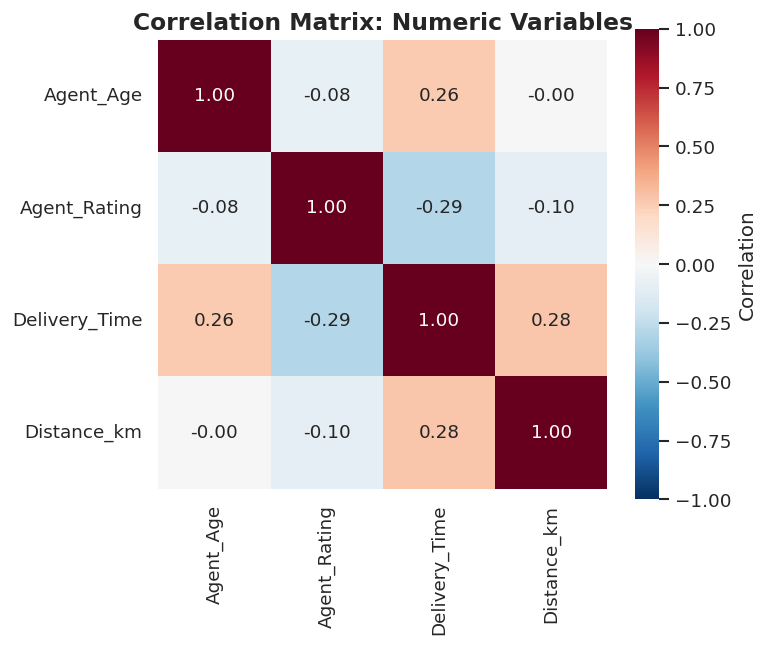

In [ ]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            fmt='.2f', square=True, cbar_kws={'label':'Correlation'})
ax.set_title('Correlation Matrix: Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Distance_km (r = 0.28) and Agent_Age (r = 0.26) correlate positively with
delivery time, while Agent_Rating correlates negatively (r = -0.29) — higher-rated agents
tend to deliver faster. None of these are strongly linear individually, suggesting delivery
time is driven more by categorical operating conditions (traffic, weather) than any single
continuous variable.

## 6. Distribution of Delivery Time

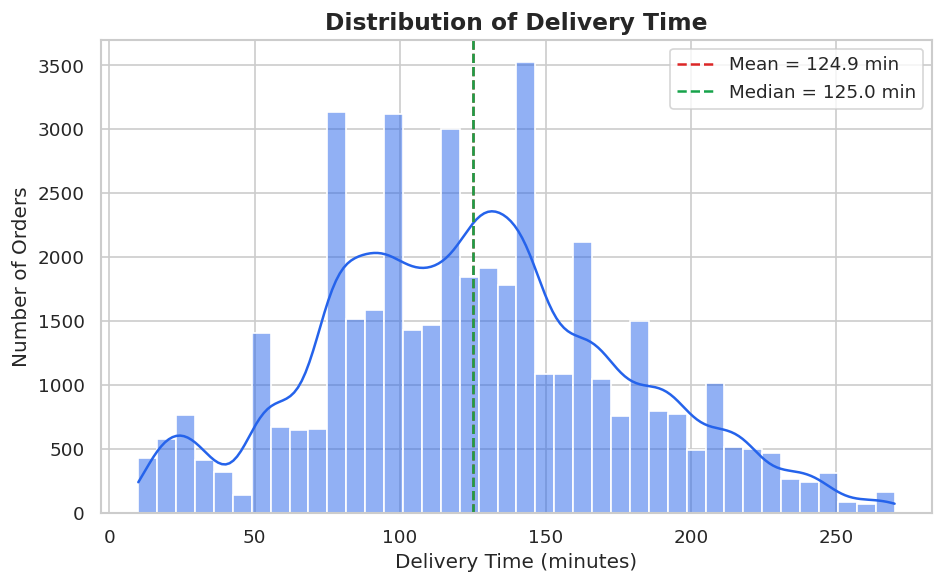

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['Delivery_Time'], bins=40, kde=True, color='#2563eb', ax=ax)
ax.axvline(df['Delivery_Time'].mean(), color='#dc2626', linestyle='--',
           label=f"Mean = {df['Delivery_Time'].mean():.1f} min")
ax.axvline(df['Delivery_Time'].median(), color='#16a34a', linestyle='--',
           label=f"Median = {df['Delivery_Time'].median():.1f} min")
ax.set_title('Distribution of Delivery Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Time (minutes)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Delivery Time by Weather

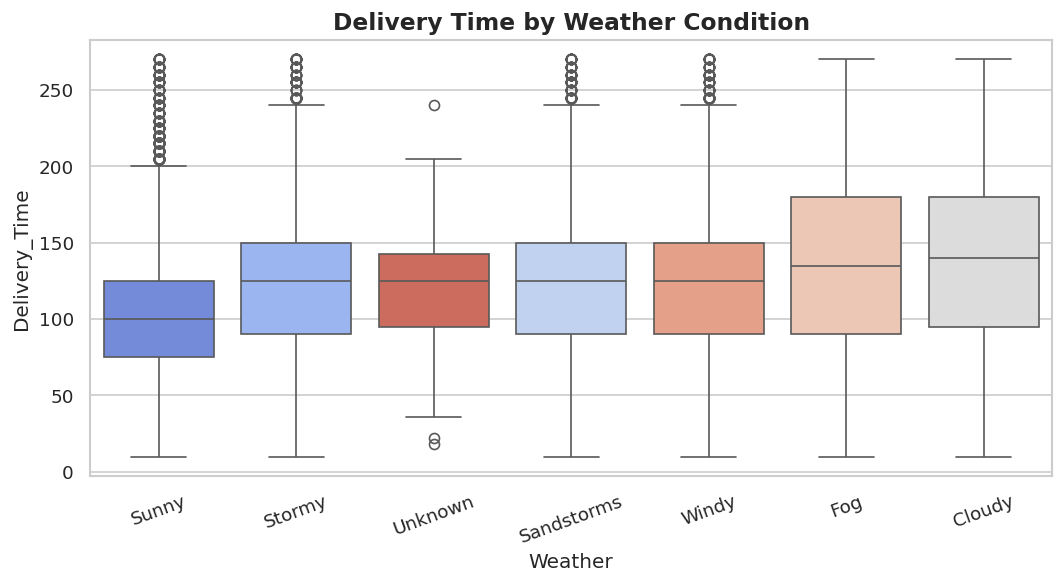

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
order = df.groupby('Weather')['Delivery_Time'].median().sort_values().index
sns.boxplot(data=df, x='Weather', y='Delivery_Time', order=order, hue='Weather',
            legend=False, ax=ax, palette='coolwarm')
ax.set_title('Delivery Time by Weather Condition', fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Insight:** Cloudy conditions show the longest median delivery times; Sunny is fastest.

## 8. Delivery Time by Traffic Density

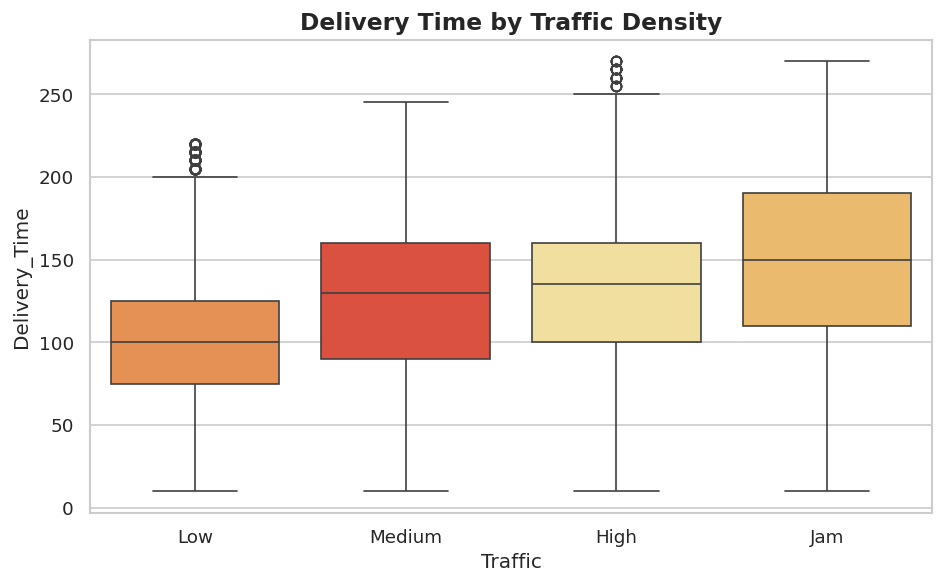

Jam vs Low average gap: 46.4 minutes


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
traffic_order = [t for t in ['Low','Medium','High','Jam'] if t in df['Traffic'].unique()]
sns.boxplot(data=df, x='Traffic', y='Delivery_Time', order=traffic_order, hue='Traffic',
            legend=False, ax=ax, palette='YlOrRd')
ax.set_title('Delivery Time by Traffic Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

gap = df[df.Traffic=='Jam']['Delivery_Time'].mean() - df[df.Traffic=='Low']['Delivery_Time'].mean()
print(f"Jam vs Low average gap: {gap:.1f} minutes")

**Insight:** Traffic is the strongest categorical driver of delay — Jam adds ~46 minutes on average vs. Low traffic.

## 9. Delivery Time by Vehicle Type

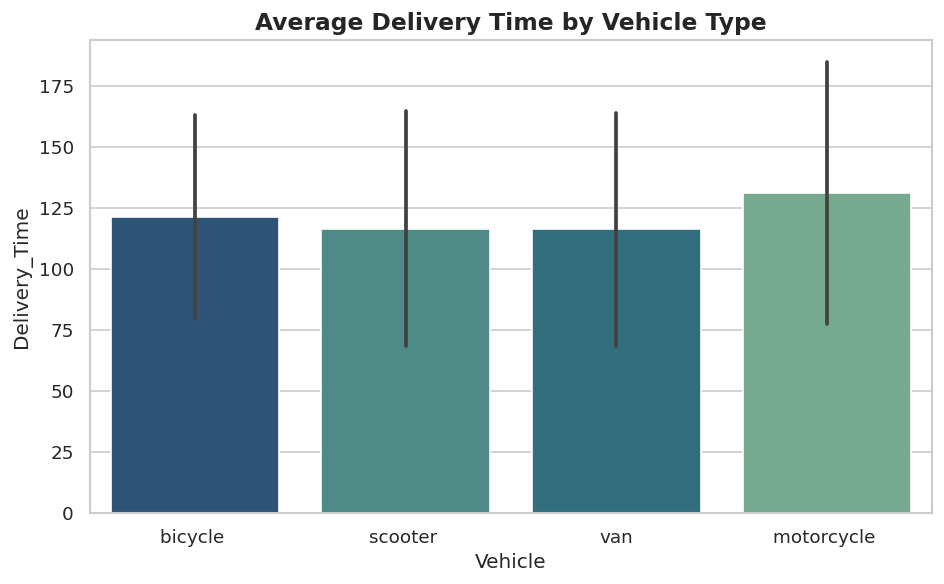

Vehicle
van            116.212181
scooter        116.369908
bicycle        121.363636
motorcycle     131.050299
Name: Delivery_Time, dtype: float64

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
veh_order = df.groupby('Vehicle')['Delivery_Time'].median().sort_values().index
sns.barplot(data=df, x='Vehicle', y='Delivery_Time', order=veh_order, hue='Vehicle',
            legend=False, ax=ax, palette='crest', errorbar='sd')
ax.set_title('Average Delivery Time by Vehicle Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df.groupby('Vehicle')['Delivery_Time'].mean().sort_values()

## 10. Delivery Time by Area Type

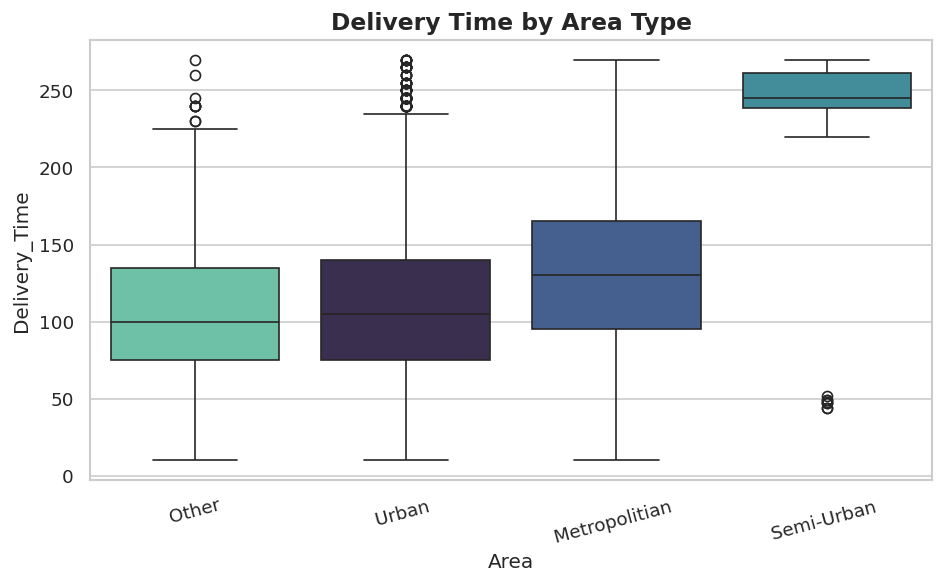

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
area_order = df.groupby('Area')['Delivery_Time'].median().sort_values().index
sns.boxplot(data=df, x='Area', y='Delivery_Time', order=area_order, hue='Area',
            legend=False, ax=ax, palette='mako')
ax.set_title('Delivery Time by Area Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 11. Delivery Time vs. Distance

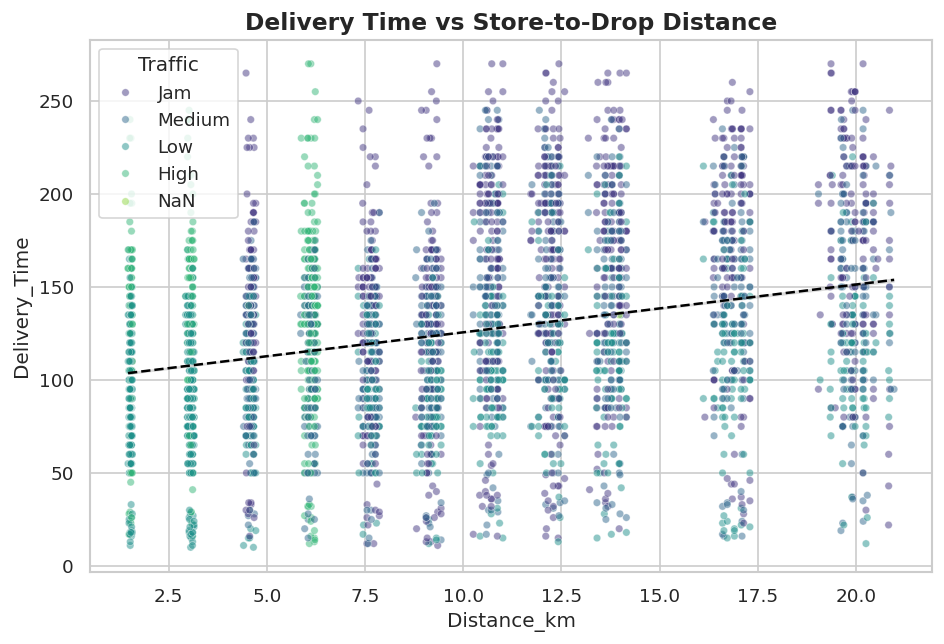

In [ ]:
fig, ax = plt.subplots(figsize=(8,5.5))
sample = df.sample(min(4000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='Distance_km', y='Delivery_Time', hue='Traffic',
                 alpha=0.5, s=20, ax=ax, palette='viridis')
sns.regplot(data=df, x='Distance_km', y='Delivery_Time', scatter=False, ax=ax,
            color='black', line_kws={'linestyle':'--','linewidth':1.5})
ax.set_title('Delivery Time vs Store-to-Drop Distance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Delivery Time by Product Category

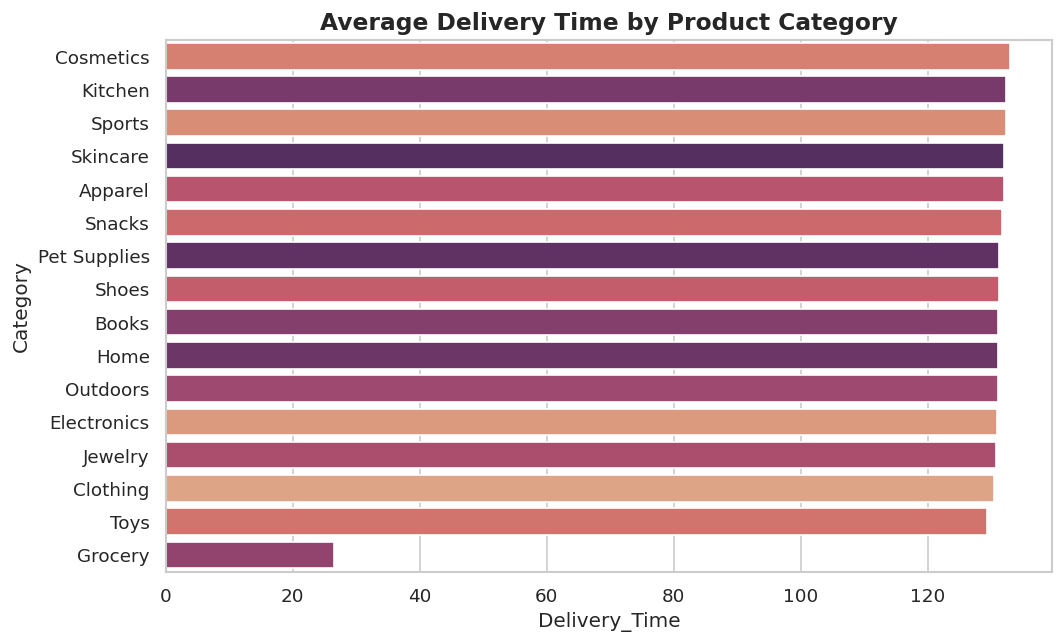

In [ ]:
fig, ax = plt.subplots(figsize=(9,5.5))
cat_order = df.groupby('Category')['Delivery_Time'].mean().sort_values(ascending=False).index
sns.barplot(data=df, y='Category', x='Delivery_Time', order=cat_order, hue='Category',
            legend=False, ax=ax, palette='flare', errorbar=None)
ax.set_title('Average Delivery Time by Product Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Order Volume by Hour of Day

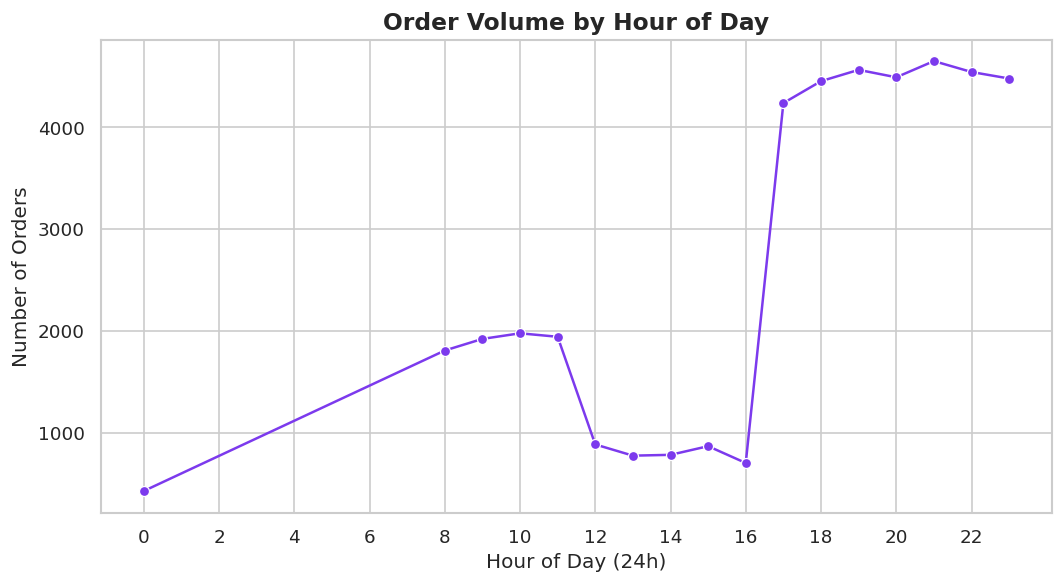

Peak order hour: 21.0


In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
hourly = df.groupby('Order_Hour').size()
sns.lineplot(x=hourly.index, y=hourly.values, marker='o', ax=ax, color='#7c3aed')
ax.set_title('Order Volume by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Number of Orders')
ax.set_xticks(range(0,24,2))
plt.tight_layout()
plt.show()

print("Peak order hour:", hourly.idxmax())

## 14. Agent Rating vs. Delivery Time

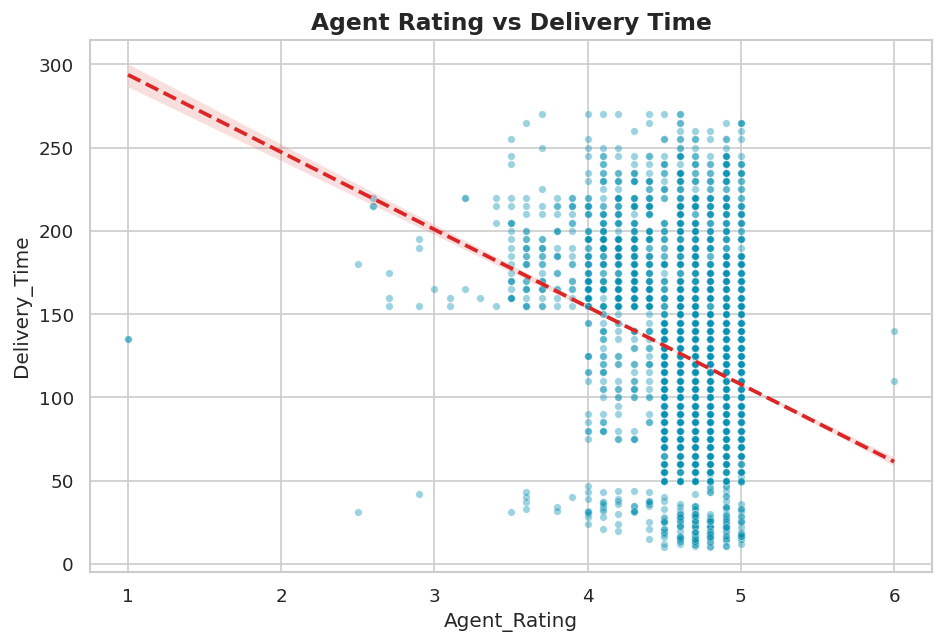

In [ ]:
fig, ax = plt.subplots(figsize=(8,5.5))
sns.scatterplot(data=sample, x='Agent_Rating', y='Delivery_Time', alpha=0.4, s=20,
                 ax=ax, color='#0891b2')
sns.regplot(data=df, x='Agent_Rating', y='Delivery_Time', scatter=False, ax=ax,
            color='#dc2626', line_kws={'linestyle':'--'})
ax.set_title('Agent Rating vs Delivery Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Analytical Insights Summary

- **Traffic** is the strongest single driver of delay: Jam conditions add ~46 minutes on average vs. Low traffic.
- **Distance** is positively but only moderately correlated with delivery time (r = 0.28), since traffic and weather modulate its effect.
- **Agent rating** correlates with speed (r = -0.29) — a usable dispatch-prioritization signal.
- **Semi-Urban areas** and **Cloudy weather** are consistent bottleneck conditions.
- **Order volume peaks around 21:00**, indicating a demand surge window for staffing.
- **Grocery** is fulfilled fastest, **Cosmetics** slowest among categories.

## 16. Recommendations

1. Build traffic-aware dispatch/routing to avoid known Jam windows.
2. Introduce weather-adjusted SLAs for Cloudy/Stormy conditions.
3. Increase agent capacity ahead of the ~21:00 demand peak.
4. Prioritize higher-rated agents for time-sensitive or long-distance orders.
5. Investigate Semi-Urban logistics infrastructure given its higher delivery times.
6. Correct Agent_Rating values exceeding the 1–5 scale at the data source.

## 17. Conclusion

This advanced EDA engineered a new distance feature and quantified how traffic, weather,
vehicle type, area, and agent quality jointly shape delivery time. Traffic emerged as the
dominant, most actionable factor. These findings set up a natural next step: a predictive
model for delivery time using these engineered features.